In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g_szt = np.array([
    1, 3, 5, 7, 10, 13, 15, 17, 20, 23,
    27, 30, 33, 36, 40, 45, 50, 55, 60, 65,
    70, 75, 80, 85, 90, 100, 120, 150, 170, 200
])

price_1g = np.array([
    99.75, 60.00, 37.50, 28.12, 23.71, 21.56, 20.58, 19.79, 18.85, 18.09,
    17.26, 16.73, 16.25, 15.81, 15.28, 14.69, 14.15, 13.67, 13.22, 12.80,
    12.42, 12.06, 11.72, 11.41, 11.12, 10.60, 9.76, 8.96, 8.70, 8.68
])

price_1st = np.array([
    0.0998, 0.1800, 0.1875, 0.1969, 0.2371, 0.2803, 0.3087, 0.3365, 0.3770, 0.4161,
    0.4660, 0.5018, 0.5362, 0.5692, 0.6114, 0.6611, 0.7077, 0.7517, 0.7930, 0.8321,
    0.8692, 0.9043, 0.9379, 0.9700, 1.0009, 1.0599, 1.1714, 1.3441, 1.4787, 1.7356
])

W = np.array([
    13.300, 8.000, 5.000, 3.750, 3.161, 2.875, 2.744, 2.639, 2.513, 2.412,
    2.301, 2.230, 2.166, 2.108, 2.038, 1.959, 1.887, 1.822, 1.762, 1.707,
    1.656, 1.608, 1.563, 1.522, 1.483, 1.413, 1.302, 1.195, 1.160, 1.157
])

df = pd.DataFrame({
    "g_szt": g_szt,
    "price_1g": price_1g,
    "price_1st": price_1st,
    "W": W
})

df

,g_szt,price_1g,price_1st,W
0,1,99.75,0.0998,13.300
1,3,60.00,0.1800,8.000
2,5,37.50,0.1875,5.000
3,7,28.12,0.1969,3.750
4,10,23.71,0.2371,3.161
5,13,21.56,0.2803,2.875
6,15,20.58,0.3087,2.744
7,17,19.79,0.3365,2.639
8,20,18.85,0.3770,2.513
9,23,18.09,0.4161,2.412


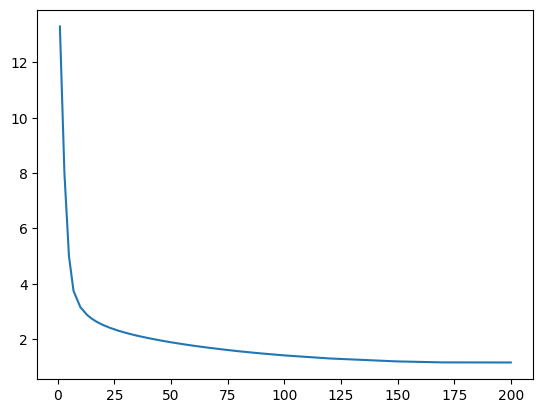

In [2]:
plt.plot(g_szt, W)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_exp_decay(x, y, plot=True):
    """
    Fits y = c + A * exp(-k * x)

    Returns:
        params: dict with A, k, c
        y_fit: fitted values at x
        r2: coefficient of determination
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Exponential decay model with horizontal asymptote c
    def model(x, A, k, c):
        return c + A * np.exp(-k * x)

    # Initial guesses
    c0 = y.min()
    A0 = y.max() - y.min()
    k0 = 0.05

    p0 = [A0, k0, c0]

    # Optional bounds: A > 0, k > 0, c >= 0
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])

    popt, pcov = curve_fit(model, x, y, p0=p0, bounds=bounds, maxfev=10000)

    A, k, c = popt

    y_fit = model(x, A, k, c)

    # R^2 score
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    params = {
        "A": A,
        "k": k,
        "c": c,
        "equation": f"W(g) = {c:.4f} + {A:.4f} * exp(-{k:.4f} * g)",
        "r2": r2
    }

    if plot:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        y_smooth = model(x_smooth, A, k, c)

        plt.scatter(x, y, label="Data")
        plt.plot(x_smooth, y_smooth, label="Exponential fit")
        plt.xlabel("g/szt.")
        plt.ylabel("W")
        plt.legend()
        plt.grid(True)
        plt.show()

        print(params["equation"])
        print(f"R² = {r2:.5f}")

    return params, y_fit, r2

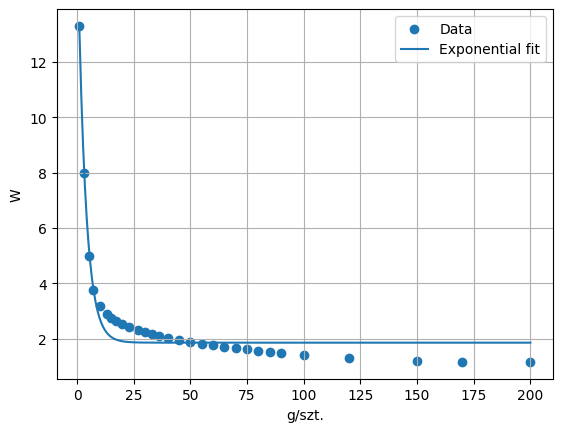

W(g) = 1.8530 + 14.9634 * exp(-0.2856 * g)
R² = 0.96814


In [4]:
params, y_fit, r2 = fit_exp_decay(g_szt, W)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect

def fit_model(x, y, model, p0=None, bounds=(-np.inf, np.inf), plot=True,
              xlabel="x", ylabel="y", label="fit"):
    """
    Generic curve fitting function.

    Fits any model of the form:

        model(x, param1, param2, ...)

    Parameters
    ----------
    x, y : array-like
        Data to fit.
    model : callable
        Function like model(x, a, b) or model(x, a, b, c), etc.
    p0 : list/tuple/array, optional
        Initial guess for parameters. If None, uses all ones.
    bounds : tuple, optional
        Bounds for parameters, passed to scipy.optimize.curve_fit.
    plot : bool
        Whether to plot data and fitted curve.
    xlabel, ylabel : str
        Axis labels.
    label : str
        Label for fitted curve.

    Returns
    -------
    result : dict
        Contains fitted parameters, covariance matrix, fitted y values, and R^2.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Count number of model parameters automatically
    # model has arguments: x, param1, param2, ...
    n_params = len(inspect.signature(model).parameters) - 1

    if p0 is None:
        p0 = np.ones(n_params)

    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    y_fit = model(x, *popt)

    # R^2
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Try to extract parameter names from the model function
    param_names = list(inspect.signature(model).parameters.keys())[1:]

    params = {
        name: value for name, value in zip(param_names, popt)
    }

    result = {
        "params": params,
        "popt": popt,
        "pcov": pcov,
        "y_fit": y_fit,
        "r2": r2
    }

    if plot:
        x_smooth = np.linspace(x.min(), x.max(), 500)
        y_smooth = model(x_smooth, *popt)

        plt.scatter(x, y, label="Data")
        plt.plot(x_smooth, y_smooth, label=label)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.legend()
        plt.show()

        print("Fitted parameters:")
        for name, value in params.items():
            print(f"{name} = {value:.6g}")

        print(f"R² = {r2:.6f}")

    return result

In [6]:
def power_law_price(W, a, b):
    return a * W**b

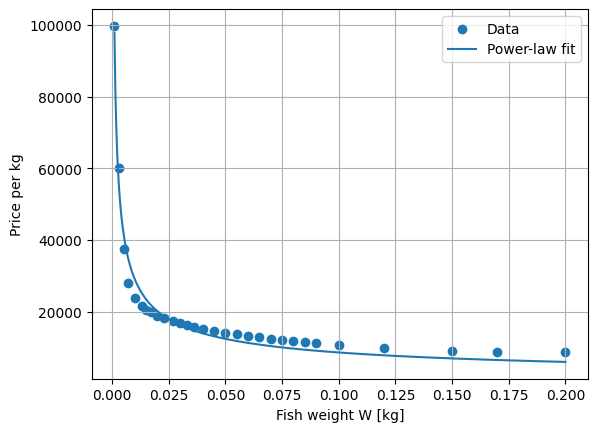

Fitted parameters:
a = 2546.06
b = -0.528214
R² = 0.977029


In [7]:
# If g_szt is in grams, convert to kg
weight_kg = g_szt / 1000

# price_1g is price per gram, so price per kg is:
price_per_kg = price_1g * 1000

result = fit_model(
    weight_kg,
    price_per_kg,
    power_law_price,
    p0=[10, -0.5],
    bounds=([0, -np.inf], [np.inf, np.inf]),
    xlabel="Fish weight W [kg]",
    ylabel="Price per kg",
    label="Power-law fit"
)

In [9]:


def coefficient(waga_szt):
    return np.interp(waga_szt, g_szt, W)

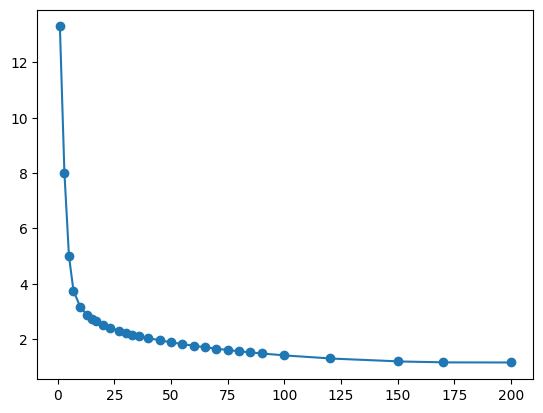

In [ ]:
n_points = 1000
waga_list = np.linspace(1,200, n_points)

# # test
# plt.plot(waga_list, coefficient(waga_list))
# plt.scatter(g_szt, W)